In [64]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline

In [65]:
data = pd.read_parquet("chicago_sales_with_crime.parquet")

In [66]:
features_to_exclude = ["pin","is_multisale", "sale_filter_same_sale_within_365", "sale_filter_less_than_10k", "single_v_multi_family", "zip_code",
                      "longitude", "latitude", "sale_date_parsed", "class", 'centroid_x_crs_3435', 'centroid_y_crs_3435', 
                       "school_elementary_district_name", "school_secondary_district_name", "township_code",  "neighborhood_code"]

In [67]:
features = []
for c in data.columns:
    if c in features_to_exclude:
        continue
    features.append(c)

In [68]:
cat_cols = ["type_of_residence", "construction_quality", "attic_finish", "garage_size",
            "basement_type", "ext_wall_material", "repair_condition", "basement_finish",
            "central_heating", "central_air", "community_area"]

for col in cat_cols:
    data[col] = data[col].astype("category")

# Drop or engineer PIN columns
data = data.drop(columns=["pin10", "nearest_new_construction_pin10", "nearest_vacant_land_pin10",
                       "nearest_neighbor_1_pin10", "nearest_neighbor_2_pin10", "nearest_neighbor_3_pin10"])

In [69]:
for c in ["pin10", "nearest_new_construction_pin10", "nearest_vacant_land_pin10",
                       "nearest_neighbor_1_pin10", "nearest_neighbor_2_pin10", "nearest_neighbor_3_pin10", "sale_date"]:
    features.remove(c)

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 1. Split: train / dev / test (e.g. 70/15/15) ---
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42
    # 0.1765 * 0.85 ≈ 0.15 → so final split is ~70/15/15
)

print(f"Train: {len(X_train)}, Dev: {len(X_dev)}, Test: {len(X_test)}")

# --- 2. Fit with a large n_estimators + early stopping on dev set ---
model = xgb.XGBRegressor(
    n_estimators=2000,          # set high — early stopping will cut it short
    learning_rate=0.05,
    max_depth=6,
    tree_method="hist",
    enable_categorical=True,    # since you have categorical columns
    early_stopping_rounds=50,   # stop if dev RMSE doesn't improve for 50 rounds
    eval_metric="rmse",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_dev, y_dev)],
    verbose=False
)

best_n_estimators = model.best_iteration
print(f"Best number of estimators: {best_n_estimators}")
print(f"Best dev RMSE: {model.best_score}")

Train: 39638, Dev: 8496, Test: 8495
Best number of estimators: 574
Best dev RMSE: 161473.2102083191


In [73]:
y=data["sale_price"]
features.remove("sale_price")
X=data[features]
model = xgb.XGBRegressor(n_estimators=574, max_depth=5, learning_rate=0.1, random_state=42, enable_categorical=True, tree_method="hist")

# 2. Set up cross-validation splitting strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Run cross-validation with multiple scoring metrics
scoring = {
    "r2": "r2",
    "neg_mae": "neg_mean_absolute_error",
    "neg_rmse": "neg_root_mean_squared_error"
}

results = cross_validate(
    model, X, y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# 4. Summarize results
print("R²:    mean = {:.4f}, std = {:.4f}".format(
    results["test_r2"].mean(), results["test_r2"].std()))
print("MAE:   mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_mae"].mean(), results["test_neg_mae"].std()))
print("RMSE:  mean = {:.4f}, std = {:.4f}".format(
    -results["test_neg_rmse"].mean(), results["test_neg_rmse"].std()))

# Optional: compare to train scores to check for overfitting
print("\nTrain R² (for comparison): {:.4f}".format(results["train_r2"].mean()))

R²:    mean = 0.8764, std = 0.0400
MAE:   mean = 86661.2547, std = 601.0441
RMSE:  mean = 161601.8219, std = 25076.3674

Train R² (for comparison): 0.9656


In [74]:
model = xgb.XGBRegressor(n_estimators=574, max_depth=5, learning_rate=0.1, random_state=42, enable_categorical=True, tree_method="hist")
model.fit(X,y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [75]:
import matplotlib.pyplot as plt

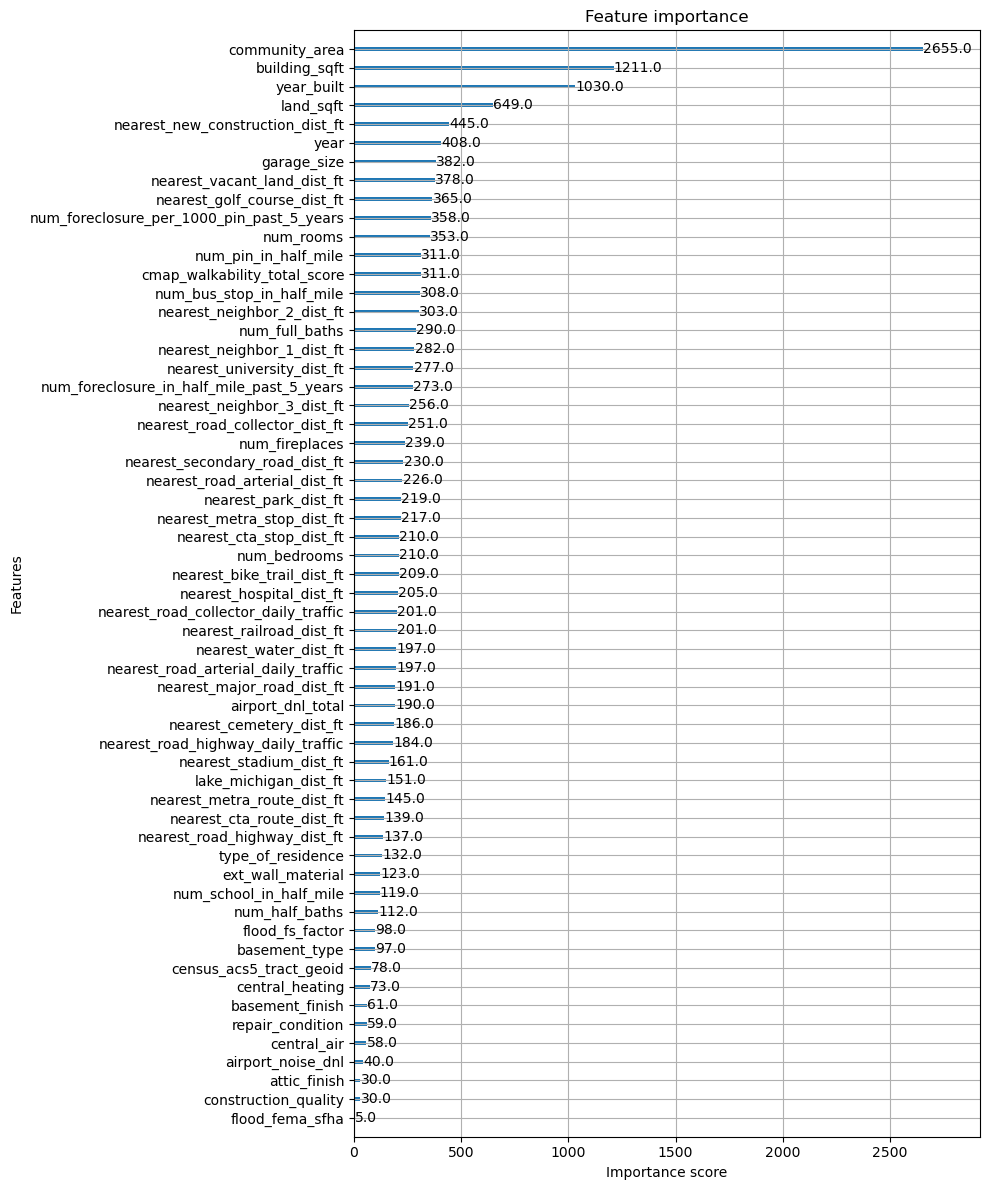

In [76]:
fig, ax = plt.subplots(figsize=(10, 12))  # wider and taller
xgb.plot_importance(model, ax=ax)
plt.tight_layout()
plt.show()

In [77]:
def categorical_pdp(model, X, feature, categories=None):
    """
    Compute partial dependence (marginal expected value) for a categorical feature.
    
    model: fitted XGBRegressor (enable_categorical=True)
    X: DataFrame used for prediction (same columns/dtypes as training)
    feature: name of the categorical column
    categories: optional list/order of categories to evaluate; defaults to all observed categories
    """
    if categories is None:
        categories = X[feature].cat.categories if hasattr(X[feature], "cat") else X[feature].unique()

    results = []
    X_temp = X.copy()

    for cat in categories:
        X_temp[feature] = cat
        # preserve categorical dtype/categories so xgboost doesn't complain
        X_temp[feature] = X_temp[feature].astype(X[feature].dtype)
        preds = model.predict(X_temp)
        results.append({"category": cat, "mean_prediction": preds.mean(), "std_prediction": preds.std()})

    return pd.DataFrame(results).sort_values("mean_prediction", ascending=False)

pdp_data = categorical_pdp(model, X, "community_area")
print(pdp_data.to_string(index=False))

 category  mean_prediction  std_prediction
        7    928221.750000   446951.781250
        8    856572.562500   402280.281250
        6    801491.250000   414745.500000
       24    791545.250000   422335.500000
        5    745084.875000   405616.156250
       33    743725.625000   348364.125000
       22    732607.750000   424222.468750
       41    731194.562500   333036.312500
       77    707616.250000   372281.187500
        3    668576.375000   363994.468750
        4    619023.312500   351701.531250
       14    575111.750000   451618.750000
       16    571833.812500   278259.312500
       21    553939.562500   279944.000000
       28    544076.562500   294605.750000
       39    530895.812500   259464.250000
       12    508222.187500   224715.593750
       34    502069.468750   198671.046875
        2    493138.750000   210498.453125
       31    491699.187500   269602.750000
       13    486466.937500   213760.562500
       60    486042.187500   225519.750000
        9  